In [1]:
import numpy as np
import pandas as pd
import regex 
import unicodedata
import matplotlib.pyplot as plt
import nltk

In [2]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [3]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\panlw\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\panlw\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\panlw\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [4]:
total_df = pd.read_csv(r"data\all_data.csv")
total_score_df = pd.read_csv('data/all_data_scores.csv', lineterminator = "\n")
cols_sentences = ['Upside_Review', 'Downside_Review']
cols_score_sentences =['Upside_Review', 'Downside_Review', "text"]
# total_df.head()

In [5]:
# punctuation symbols and space
PUNC_SYS = regex.compile(r"[\p{P}\p{S}]")
SPACES = regex.compile(r"\s+")

def punct_clean(text):
    text = unicodedata.normalize("NFKC", text)
    text = PUNC_SYS.sub(" ", text)
    text = SPACES.sub(" ", text)
    return text.strip()



In [6]:
LANG_MAP = {"English": "english", "French": "french", "German": "german",
            "Italian": "italian", "Spanish": "spanish", "Russian": "russian",
            "Romanian": "romanian", "Turkish": "turkish", "Chinese": "chinese"}
STOPWORDS= {lang: set(stopwords.words(nltk_name))
            for lang, nltk_name in LANG_MAP.items()
            if nltk_name in  stopwords.fileids()}

def preprocessing_text(text, lang):
    """
    Include stopword removal + tokenization
    """
    if not text:
        return []

    text = text.lower()
    tokens = text.split()
    sw = STOPWORDS.get(lang, set())
    filtered_tokens = [word for word in tokens if word not in sw]
    return filtered_tokens

    

In [7]:
test = total_df[cols_sentences].iloc[:5]


the following cell display the tokenizer for chinese only breaks on spaces not words

In [8]:
test = total_df[cols_sentences + ["Review_Language"]].iloc[:5].copy()
test[cols_sentences] = test[cols_sentences].map(punct_clean, na_action="ignore").fillna("")

for col in cols_sentences:
    test[col] = [preprocessing_text(t, lang) for t, lang in zip(test[col], test["Review_Language"])]

test.iloc[0] 

Upside_Review      [性价比超高的酒店, 虽然价格比较贵, 但是享受到的服务环境都还不错]
Downside_Review                                     []
Review_Language                                Chinese
Name: 0, dtype: object

Use Jieba package to tokenize Chinese 

In [9]:
import jieba

def preprocessing_text(text, lang):
    """
    Include stopword removal + tokenization
    """
    if not text:
        return []

    text = text.lower()

    if lang == 'Chinese':
        tokens = [t for t in jieba.lcut(text) if t.strip() ]
    else:  
        tokens = text.split()
        
    sw = STOPWORDS.get(lang, set())
    filtered_tokens = [word for word in tokens if word not in sw]
    return filtered_tokens


In [10]:
# test on test again
test = total_df[cols_sentences + ["Review_Language"]].iloc[:5].copy()
test[cols_sentences] = test[cols_sentences].map(punct_clean, na_action="ignore").fillna("")

for col in cols_sentences:
    test[col] = [preprocessing_text(t, lang) for t, lang in zip(test[col], test["Review_Language"])]

test.iloc[0] 

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\panlw\AppData\Local\Temp\jieba.cache
Loading model cost 0.379 seconds.
Prefix dict has been built successfully.


Upside_Review      [性价比, 超高, 酒店, 价格, 贵, 享受, 服务, 环境, 都, 还, 不错]
Downside_Review                                            []
Review_Language                                       Chinese
Name: 0, dtype: object

In [11]:
total_df[cols_sentences] = total_df[cols_sentences].map(punct_clean, na_action = 'ignore').fillna(" ")

for col in cols_sentences:
    total_df[col] = [preprocessing_text(t, lang) for t, lang in zip(total_df[col], total_df['Review_Language'])]

In [12]:
total_score_df[cols_score_sentences] = total_score_df[cols_score_sentences].map(punct_clean, na_action = 'ignore').fillna(" ")

for col in cols_score_sentences:
    total_score_df[col] = [preprocessing_text(t, lang) for t, lang in zip(total_score_df[col], total_score_df['Review_Language'])]

In [31]:
# drop some columns
for d in (total_df, total_score_df):
    d['row_id'] = d['Unnamed: 0'].astype(int)
    d.drop(columns= ['Prompt_Language', 'Unnamed: 0'], inplace= True)



In [44]:
cat_cols = ["Review_Language", "City Name", "Hotel Name", "Sentiment"]
num_cols = ["Review_Score", "Analytic", "Readability", "Descriptiveness"]

# we check if the categorical columns are giving away the details to the model (some hotel's reviews might be compltetely generated)
for c in cat_cols:
    ct = pd.crosstab(total_score_df[c], total_score_df['source'], normalize= 'index') # table with one row per category and one col per class
    print(c, '-categories that are >90% one class', (ct.max(axis = 1)> 0.9).sum())
print('------------------------------------------')
print(total_score_df.groupby('source')[num_cols].mean().T)

Review_Language -categories that are >90% one class 0
City Name -categories that are >90% one class 0
Hotel Name -categories that are >90% one class 7
Sentiment -categories that are >90% one class 0
------------------------------------------
source                   0          1
Review_Score      6.634151   5.841350
Analytic         -6.274155  -5.076104
Readability      22.351238  15.073436
Descriptiveness   0.109283   0.130024


In [ ]:
# check which hotels have more than 90% same labels
ct = pd.crosstab(total_score_df['Hotel Name'], total_score_df['source'])
ct['frac_generated'] = ct[1] / ct.sum(axis = 1)
print(ct[(ct["frac_generated"] > 0.9) | (ct["frac_generated"] < 0.1)])

source               0  1  frac_generated
Hotel Name                               
Boxi Studios Berlin  0  1             1.0
Hotel Grand Inn      0  1             1.0
加特点查理酒店              0  1             1.0
柏林中央车站城际酒店           0  5             1.0
柏林亚历山大广场美宁格酒店        0  1             1.0
柏林君悦酒店               0  1             1.0
柏林哈克市场便捷酒店           0  1             1.0


In [53]:
# AUC to evaluate the performance of binary classification model
from sklearn.metrics import roc_auc_score

for col in num_cols:
    d = total_score_df[[col, 'source']].dropna()
    auc = roc_auc_score(d['source'], d[col])
    print('current col:', col)
    print(f"{c:16s} AUC  = {max(auc, 1 -auc):.3f}")
    print('-----------------')


current col: Review_Score
Sentiment        AUC  = 0.613
-----------------
current col: Analytic
Sentiment        AUC  = 0.526
-----------------
current col: Readability
Sentiment        AUC  = 0.571
-----------------
current col: Descriptiveness
Sentiment        AUC  = 0.595
-----------------


In [54]:
print(total_score_df.groupby(["Review_Language", "source"])["Readability"].median().unstack())

source                   0          1
Review_Language                      
Chinese                NaN        NaN
English          71.316522  55.441284
French           55.337865  43.936912
German           31.545000  27.490000
Italian          -5.817500 -12.392857
Korean                 NaN        NaN
Romanian         13.571748  -0.490849
Russian          -5.420000 -15.664414
Spanish          23.424958  11.780521
Turkish                NaN        NaN


In [14]:
# save the dfs into pickle

total_score_df.to_pickle('total_score_df.pkl')
total_df.to_pickle('total_df.pkl')

# use pd.read_pickle() to read

In [15]:
total_df.shape

(19985, 12)

In [16]:
total_df.isnull().sum()

Unnamed: 0            0
Review_Language       0
City Name             0
Hotel Name            0
Upside_Review         0
Downside_Review       0
Review_Score          0
Sentiment             0
source                0
Prompt_Language    9985
na_up_review          0
na_down_review        0
dtype: int64

In [17]:
total_score_df.shape

(19985, 14)

In [18]:
total_score_df.isnull().sum()

Unnamed: 0            0
Review_Language       0
City Name             0
Hotel Name            0
Upside_Review         0
Downside_Review       0
Review_Score          0
Sentiment             0
Analytic              0
source                0
Prompt_Language    9985
text                  0
Readability        5985
Descriptiveness       0
dtype: int64

# Not sure what to assing for empty Readability value


In [19]:
score_check = total_score_df[["Upside_Review", "Downside_Review", 'Readability']]
a = score_check[~score_check['Readability'].isnull()].describe()
a

,Readability
count,14000.000000
mean,18.712337
std,37.064550
min,-387.395000
25%,-6.010000
50%,18.605978
75%,45.262353
max,120.712500


In [20]:
r_missing = total_score_df["Readability"].isna()
print('readability missing', len(r_missing))

for col in ["Upside_Review", "Downside_Review", "Prompt_Language"]:
    both = (r_missing & total_score_df[col].isna()).sum()
    print(f"{col}: {both} of {r_missing.sum()} Readability-NaN rows are also NaN here")

# Rows where Readability is NaN but both reviews exist
has_text = total_score_df["Upside_Review"].notna() | total_score_df["Downside_Review"].notna()
print((r_missing & has_text).sum())


print(total_score_df.loc[r_missing, "Prompt_Language"].value_counts(dropna=False).head(10))#language breakdown of the missing rows

readability missing 19985
Upside_Review: 0 of 5985 Readability-NaN rows are also NaN here
Downside_Review: 0 of 5985 Readability-NaN rows are also NaN here
Prompt_Language: 2985 of 5985 Readability-NaN rows are also NaN here
5985
Prompt_Language
NaN                  2985
English(Korean)       191
English(Italian)      181
Italian               178
English(German)       174
English(Romanian)     174
Korean                170
Spanish               166
English(Spanish)      166
Turkish               165
Name: count, dtype: int64


C:\Users\panlw\AppData\Local\Temp\ipykernel_41924\3523436624.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(scores, vert=False)


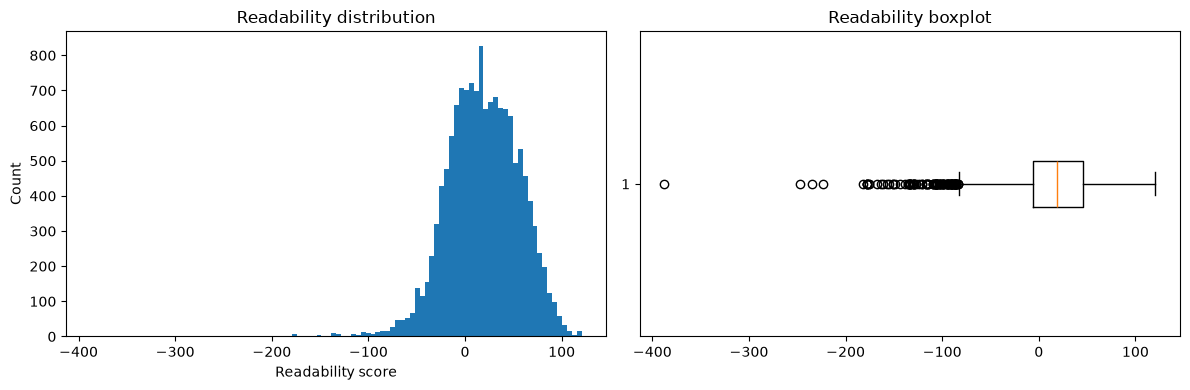

In [21]:


scores = total_score_df['Readability'].dropna()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(scores, bins=100)
axes[0].set_title("Readability distribution")
axes[0].set_xlabel("Readability score")
axes[0].set_ylabel("Count")

axes[1].boxplot(scores, vert=False)
axes[1].set_title("Readability boxplot")

plt.tight_layout()
plt.show()